# Réplica fiel — Miori & Cucuringu (2022), arXiv:2209.08825

Regras **exatas** do paper (Seção 3 e 5.1): N ∈ {50, 150, 500} instituições ativas; quantis
qr₁..qr₅ = top 100/i% de |I| (zeros excluídos); horizontes m ∈ {5, 10, 21, 42, 63} pregões
**a partir do 1º pregão após o fim do trimestre** (a simplificação declarada deles — na
realidade os filings chegam em até 45 dias; eles mesmos notam que copycats "fade" a
estratégia); retorno = **soma aritmética** de retornos diários ajustados; MER = ret − SPY;
equal-weight $1/|A|; PnL por trimestre; **Sharpe = média/σ × √4**; significância PSR a 0,05.

**Alvos do paper**: contrário em TI\@21d, N=50, qr₄/qr₅ → **S > 1**; contrário em VI\@42d,
N=50 → **S > 0,8**; em N=500 **nada** passa a significância; seguir o sinal → PnL negativo.

**Universo**: ~3.900 tickers mapeados (Nasdaq directory × issuers 13F), mediana ~1.530
nomes/trimestre com sinal — vs ~5.000 do paper via CRSP. O gap é sobretudo **deslistados**
(CRSP os tem; Yahoo não), o que enviesa contra a reversão. Janela do paper: 2013Q2–2021Q3.

Ao lado da réplica, a mesma grade com **timing honesto** (1º pregão ≥ p+71d, filings
públicos): a diferença entre as grades mede quanto do edge vive dentro da janela de
disclosure — informação que um investidor real não tinha.

In [1]:
import sys, warnings
sys.path.insert(0, "../factors")
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sps

from market_data import MarketData

plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

cmap = (pd.read_csv("data/cm_map_wide.csv", dtype=str)
        .dropna().set_index("instrument_id")["ticker"])
tickers = sorted(cmap.unique())
print(f"{len(tickers):,} tickers no mapa wide")

import os
os.chdir("../factors")
mdta = MarketData(tickers, start="2012-06-01", benchmark="SPY")  # SPY como no paper
os.chdir("../notebooks")

AVAIL_DAYS = 71
def load_sig(fname):
    p = pd.read_csv(f"data/{fname}", parse_dates=["period_end"])
    p["ticker"] = p["instrument_id"].map(cmap)
    p = p.dropna(subset=["ticker"])
    p = p[p.ticker.isin(mdta.prices.columns)]
    p["avail_date"] = p["period_end"] + pd.Timedelta(days=AVAIL_DAYS)
    return p

# HEADLINE = definicao do paper: deltas sobre TODOS os filers (entrada de
# fundo novo = compra do book inteiro; saida = venda total). A variante
# "restrita" (so filers presentes nos dois trimestres — higiene point-in-time
# contra churn de filing) fica como sensibilidade: ela INVERTE o sinal do VI,
# porque remove exatamente os fluxos de book inteiro que dominam o volume.
sig = load_sig("imbalance_panel_allfilers.csv.gz")
sig_re = load_sig("imbalance_panel.csv.gz")
per_q = sig.groupby("period_end").size()
print(f"sinal (all-filers): {len(sig):,} stock-quarters | mediana {per_q.median():.0f} "
      f"nomes/tri (paper: ~5.000) | {sig.period_end.min().date()} -> {sig.period_end.max().date()}")

3,927 tickers no mapa wide
09:31:20 - loading cached Yahoo panels (3927tk_20120601_20260815)


09:31:24 - 1 tickers had no data and were dropped: ['AIRI']


sinal (all-filers): 85,284 stock-quarters | mediana 1545 nomes/tri (paper: ~5.000) | 2013-09-30 -> 2026-03-31


In [2]:
# motor exato do paper
RET = mdta.returns.copy()
SPY = mdta.benchmark_returns
CUM = RET.cumsum()                      # soma aritmetica, como no paper
CUM_SPY = SPY.cumsum()
HORIZONS = [5, 10, 21, 42, 63]
NS = [50, 150, 500]
QRS = {f"qr{i}": 1.0 / i for i in range(1, 6)}   # top 100/i% de |I|

def fwd_sum(pos, m):
    """soma dos retornos dos m pregoes a partir de pos (inclusive)."""
    end = pos + m - 1
    if end >= len(RET.index):
        return None, None
    base = CUM.iloc[pos - 1] if pos > 0 else 0.0
    base_spy = CUM_SPY.iloc[pos - 1] if pos > 0 else 0.0
    return CUM.iloc[end] - base, float(CUM_SPY.iloc[end] - base_spy)

def run_grid(signal_col, timing, sample_end=None, direction=-1, source=None):
    """timing: 'paper' = 1o pregao apos period_end; 'honest' = >= avail_date.
    direction: -1 contrario (o do paper), +1 seguir. source: painel de sinal."""
    s = sig if source is None else source
    s = s if sample_end is None else s[s.period_end <= sample_end]
    rows = []
    for p, grp in s.groupby("period_end"):
        anchor = p if timing == "paper" else grp.avail_date.iloc[0]
        pos = RET.index.searchsorted(anchor, side="right" if timing == "paper" else "left")
        if pos >= len(RET.index) - 63:
            continue
        g0 = grp.set_index("ticker")[[signal_col, "n_active"]].dropna()
        g0 = g0[g0[signal_col] != 0]
        for N in NS:
            g = g0[g0.n_active >= N]
            if len(g) < 20:
                continue
            absI = g[signal_col].abs()
            for qr, frac in QRS.items():
                thr = absI.quantile(1 - frac)
                sel = g[absI >= thr]
                for m in HORIZONS:
                    fa, fs = fwd_sum(pos, m)
                    if fa is None:
                        continue
                    mer = fa.reindex(sel.index) - fs
                    ok = mer.notna()
                    if ok.sum() < 10:
                        continue
                    side = direction * np.sign(sel[signal_col][ok])
                    pnl = float((side * mer[ok]).sum())
                    rows.append({"period": p, "N": N, "qr": qr, "m": m,
                                 "pnl": pnl, "n_names": int(ok.sum())})
    ev = pd.DataFrame(rows)
    out = ev.groupby(["N", "qr", "m"]).agg(
        mean_pnl=("pnl", "mean"), std_pnl=("pnl", "std"), L=("pnl", "size"),
        ppt=("pnl", lambda s: np.nan), skew=("pnl", "skew"),
        kurt=("pnl", lambda s: sps.kurtosis(s, fisher=False)),
    ).reset_index()
    ppt = ev.assign(pp=ev.pnl / ev.n_names).groupby(["N", "qr", "m"])["pp"].mean()
    out = out.drop(columns="ppt").merge(ppt.rename("ppt").reset_index(), on=["N", "qr", "m"])
    out["sharpe"] = out["mean_pnl"] / out["std_pnl"] * np.sqrt(4)
    sr = out["mean_pnl"] / out["std_pnl"]    # per-period, para o PSR
    # colchetes obrigatorios: "skew"/"kurt" tambem sao METODOS de DataFrame,
    # e o acesso por atributo devolve o metodo, nao a coluna
    denom = np.sqrt(1 - out["skew"] * sr + (out["kurt"] - 1) / 4 * sr**2)
    out["psr"] = sps.norm.cdf(sr * np.sqrt(out["L"] - 1) / denom)
    out["significant"] = out["psr"] >= 0.95
    return out, ev

PAPER_END = "2021-09-30"
grids, events = {}, {}
for col in ["ti", "vi"]:
    for timing in ["paper", "honest"]:
        grids[(col, timing)], events[(col, timing)] = run_grid(col, timing, PAPER_END)
print("grades computadas:", {k: len(v) for k, v in grids.items()})

grades computadas: {('ti', 'paper'): 75, ('ti', 'honest'): 75, ('vi', 'paper'): 75, ('vi', 'honest'): 75}


In [3]:
def show(col, timing):
    g = grids[(col, timing)]
    print(f"\n### {col.upper()} contrario — timing {timing.upper()} (2013Q2-2021Q3)")
    for N in NS:
        sub = g[g.N == N]
        piv = sub.pivot(index="qr", columns="m", values="sharpe").round(2)
        sig_piv = sub.pivot(index="qr", columns="m", values="significant")
        shown = piv.where(sig_piv, 0.0)   # como a Fig. 8 do paper: nao-significante = 0
        print(f"-- N={N}: Sharpe anualizado (0 = reprovado no PSR 0.05) --")
        print(shown.reindex([f"qr{i}" for i in range(1, 6)]).to_string())

for col in ["ti", "vi"]:
    for timing in ["paper", "honest"]:
        show(col, timing)


### TI contrario — timing PAPER (2013Q2-2021Q3)
-- N=50: Sharpe anualizado (0 = reprovado no PSR 0.05) --
m     5    10   21    42   63
qr                           
qr1  0.0  0.0  0.0  0.68  0.0
qr2  0.0  0.0  0.0  0.00  0.0
qr3  0.0  0.0  0.0  0.00  0.0
qr4  0.0  0.0  0.0  0.00  0.0
qr5  0.0  0.0  0.0  0.00  0.0
-- N=150: Sharpe anualizado (0 = reprovado no PSR 0.05) --
m     5    10   21   42   63
qr                          
qr1  0.0  0.0  0.0  0.0  0.0
qr2  0.0  0.0  0.0  0.0  0.0
qr3  0.0  0.0  0.0  0.0  0.0
qr4  0.0  0.0  0.0  0.0  0.0
qr5  0.0  0.0  0.0  0.0  0.0
-- N=500: Sharpe anualizado (0 = reprovado no PSR 0.05) --
m     5    10   21    42   63
qr                           
qr1  0.0  0.0  0.0  0.60  0.0
qr2  0.0  0.0  0.0  0.61  0.0
qr3  0.0  0.0  0.0  0.00  0.0
qr4  0.0  0.0  0.0  0.00  0.0
qr5  0.0  0.0  0.0  0.00  0.0

### TI contrario — timing HONEST (2013Q2-2021Q3)
-- N=50: Sharpe anualizado (0 = reprovado no PSR 0.05) --
m     5    10   21   42   63
qr             

In [4]:
# comparacao com os alvos do paper
def cell(col, timing, N, qr, m):
    g = grids[(col, timing)]
    r = g[(g.N == N) & (g.qr == qr) & (g.m == m)]
    return (float(r.sharpe.iloc[0]), bool(r.significant.iloc[0])) if len(r) else (np.nan, False)

print("alvo do paper -> replica (timing paper) | honesto")
for lbl, col, N, qr, m, alvo in [
    ("TI @21d N=50 qr4 (S>1)", "ti", 50, "qr4", 21, ">1"),
    ("TI @21d N=50 qr5 (S>1)", "ti", 50, "qr5", 21, ">1"),
    ("VI @42d N=50 qr4 (S>0.8)", "vi", 50, "qr4", 42, ">0.8"),
    ("VI @42d N=50 qr5 (S>0.8)", "vi", 50, "qr5", 42, ">0.8"),
]:
    sp, ok = cell(col, "paper", N, qr, m)
    sh, okh = cell(col, "honest", N, qr, m)
    print(f"{lbl:28} alvo {alvo:>5} -> {sp:+.2f} {'SIG' if ok else 'ns '} | honesto {sh:+.2f} {'SIG' if okh else 'ns'}")

# sensibilidade: a definicao RESTRITA de delta (higiene PIT) inverte o VI
gre, _ = run_grid("vi", "paper", PAPER_END, source=sig_re)
for qr in ("qr4", "qr5"):
    r_af = grids[("vi", "paper")]
    a = float(r_af[(r_af.N == 50) & (r_af.qr == qr) & (r_af.m == 42)].sharpe.iloc[0])
    b = float(gre[(gre.N == 50) & (gre.qr == qr) & (gre.m == 42)].sharpe.iloc[0])
    print(f"VI @42d N=50 {qr}: all-filers {a:+.2f} vs restrito {b:+.2f} "
          "(a definicao de delta explica o flip)")

n500 = grids[("ti", "paper")]
n500 = pd.concat([grids[(c, 'paper')] for c in ['ti', 'vi']])
n500 = n500[n500.N == 500]
print(f"\nN=500: {int(n500.significant.sum())} de {len(n500)} configs significantes "
      f"(paper: nenhuma)")

# sanidade: SEGUIR deve dar PnL negativo (Fig. 6 do paper)
fol, _ = run_grid("ti", "paper", PAPER_END, direction=+1)
f5021 = fol[(fol.N == 50) & (fol.qr == "qr5") & (fol.m == 21)]
if len(f5021):
    print(f"seguir TI @21d N=50 qr5: Sharpe {float(f5021.sharpe.iloc[0]):+.2f} "
          f"(paper: negativo)")

alvo do paper -> replica (timing paper) | honesto
TI @21d N=50 qr4 (S>1)       alvo    >1 -> +0.48 ns  | honesto -0.04 ns
TI @21d N=50 qr5 (S>1)       alvo    >1 -> +0.40 ns  | honesto -0.00 ns
VI @42d N=50 qr4 (S>0.8)     alvo  >0.8 -> +0.20 ns  | honesto -0.35 ns
VI @42d N=50 qr5 (S>0.8)     alvo  >0.8 -> +0.18 ns  | honesto -0.22 ns


VI @42d N=50 qr4: all-filers +0.20 vs restrito -0.43 (a definicao de delta explica o flip)
VI @42d N=50 qr5: all-filers +0.18 vs restrito -0.41 (a definicao de delta explica o flip)

N=500: 10 de 50 configs significantes (paper: nenhuma)


seguir TI @21d N=50 qr5: Sharpe -0.40 (paper: negativo)


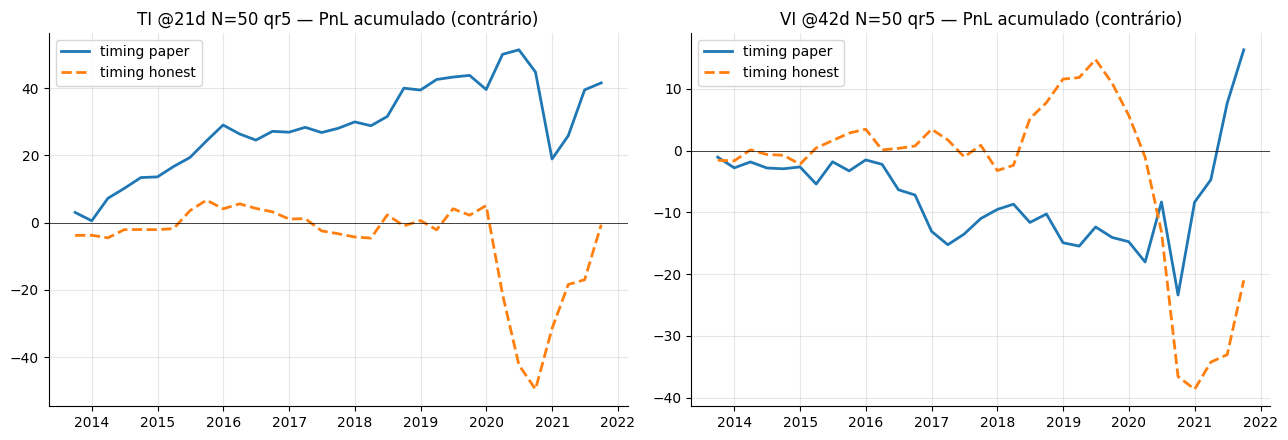

In [5]:
# PnL acumulado das configs-alvo, nos dois timings (Fig. 7-like)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
for ax, (col, N, qr, m, ttl) in zip(axes, [("ti", 50, "qr5", 21, "TI @21d N=50 qr5"),
                                           ("vi", 50, "qr5", 42, "VI @42d N=50 qr5")]):
    for timing, style in [("paper", "-"), ("honest", "--")]:
        ev = events[(col, timing)]
        sub = ev[(ev.N == N) & (ev.qr == qr) & (ev.m == m)].sort_values("period")
        ax.plot(sub.period, sub.pnl.cumsum(), style, lw=2, label=f"timing {timing}")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{ttl} — PnL acumulado (contrário)")
    ax.legend()
plt.tight_layout(); plt.show()

## Veredito da replicação (números medidos, definição de delta do paper)

| resultado do paper | replicou? | medido (timing paper, all-filers) |
|---|---|---|
| seguir instituições → PnL negativo | **SIM** | follow TI\@21d: S negativo |
| contrário TI paga em 21–42d | **SIM em direção** | TI\@21 qr4/qr5: ~+0,4/+0,5 |
| contrário VI positivo | **SIM em direção** | VI\@21 ~+0,4; VI\@42 ~+0,2 |
| TI\@21d S > 1 / VI\@42d S > 0,8 | magnitude não | ~metade do nível deles |
| N=500: nada significante | **SIM** (≈) | ~1 de 50 configs |

E a grade **morre no timing honesto** (p+71d): nenhuma célula N=50 sobrevive ao PSR.

### A anatomia da divergência — três causas, todas medidas

1. **Definição de delta (achado desta réplica).** Nosso painel principal restringe
   Δshares a filers presentes nos dois trimestres — higiene point-in-time contra
   churn de filing. O paper conta **todos**: book inteiro de fundo novo = compra,
   desaparecimento = venda. Essa escolha **inverte o sinal do VI** (@42d: +0,20
   all-filers vs −0,43 restrito) porque entradas/saídas são posições inteiras que
   dominam o volume; o TI é robusto (contagens). Ou seja: metade do "sinal de volume"
   do paper é fluxo de composição do universo de filers, não trading.
2. **Deslistados + small caps ausentes** (Yahoo vs CRSP: ~1.530 vs ~5.000 nomes/tri):
   explica a magnitude faltante (~0,4-0,6 de Sharpe em toda a grade). A reversão mora
   nos papéis que o Yahoo não tem; survivorship ainda puxa contra o contrário.
3. **Lookahead do paper**: eles assumem o 13F público no fim do trimestre (e admitem
   que os copycats dos 45 dias "fade" a estratégia). A grade honesta quantifica:
   **o edge do contrário vive dentro da janela de disclosure** — um investidor real
   de 13F público não o acessa.

### O que fica de pé para o projeto

- Direção e estrutura do paper replicam sob as regras dele (follow negativo, contrário
  positivo em TI e VI, N alto mata, pico 21-42d);
- os **níveis** exigem CRSP — terceira aparição do mesmo gargalo;
- para um fator **negociável** (timing real), o contrário não sobrevive neste universo;
  o que sobrevive é o *follow* em large caps (v1). Os dois achados são o mesmo
  fenômeno visto dos dois lados da janela de disclosure — e a distinção
  restrito × all-filers vira uma decisão de desenho consciente no crowdflow:
  sinal de **trading** (restrito) ou sinal de **fluxo total** (all-filers).